# Prediksi Suara buka tutup

## Import ibrary yang dibutuhkan

In [1]:
!pip install scipy
!pip install scikit-learn

In [2]:
!pip install tsfel librosa pandas numpy scipy streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 33.8 MB/s eta 0:00:00


In [ ]:
# Hapus instalasi lama dan instal ulang versi terbaru
!pip uninstall -y tsfel
!pip install --upgrade --force-reinstall tsfel numpy pandas scipy librosa soundfile

Found existing installation: tsfel 0.2.0
Uninstalling tsfel-0.2.0:
  Successfully uninstalled tsfel-0.2.0
  Using cached tsfel-0.2.0-py3-none-any.whl.metadata (9.4 kB)
  Using cached numpy-2.3.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
  Using cached scipy-1.16.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (62 kB)
  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached soundfile-0.13.1-py2.py3-none-manylinux_2_28_x86_64.whl.metadata (16 kB)
  Using cached ipython-9.6.0-py3-none-any.whl.metadata (4.4 kB)
  Using cached pywavelets-1.9.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (7.6 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached scikit_learn-1.7.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached s

## Ekstrak audio menjadi fitur statistik

In [ ]:
import tsfel
import librosa
import numpy as np
import pandas as pd
import io
from google.colab import files # For file upload in Colab
from IPython.display import display # For displaying DataFrames nicely

# --- PERBAIKAN: Gunakan tsfel.get_features_by_domain() untuk mendapatkan SEMUA 156+ fitur ---
try:
    print("Memuat konfigurasi TSFEL untuk mengekstrak SEMUA 156+ fitur...")

    # Memanggil tsfel.get_features_by_domain() (atau domain=None)
    # adalah cara yang benar untuk mengambil SEMUA fitur
    cfg_gabungan = tsfel.get_features_by_domain()

    # Hitung total fitur dari kamus yang dikembalikan
    num_features_stat = len(cfg_gabungan.get("statistical", {}))
    num_features_spec = len(cfg_gabungan.get("spectral", {}))
    num_features_temp = len(cfg_gabungan.get("temporal", {}))
    num_total = num_features_stat + num_features_spec + num_features_temp

    print(f"✅ Konfigurasi TSFEL (SEMUA) berhasil dimuat.")
    print(f"   Fitur Statistik: {num_features_stat}")
    print(f"   Fitur Spektral:  {num_features_spec}")
    print(f"   Fitur Temporal:  {num_features_temp}")
    print(f"   Total Fitur:     {num_total} (expected ~156+)")

    if num_total < 100: # Pengecekan keamanan
         print("⚠️ Peringatan: Total fitur kurang dari 100. Pastikan TSFEL terinstal penuh.")

except Exception as e:
    print(f"❌ Gagal memuat konfigurasi TSFEL: {e}")
    # Jika konfigurasi gagal, kita hentikan
    cfg_gabungan = None # Set status error

# List kosong untuk menampung semua DataFrame hasil
all_features_list = []

# --- Cek cfg_gabungan ---
# (Kita cek apakah cfg_gabungan tidak None dan tidak kosong)
if cfg_gabungan: # Hanya lanjut jika konfigurasi berhasil dimuat
    # --- 2. Upload File (Bisa lebih dari 1) ---
    print("\nSilakan unggah file MP3 Anda (bisa pilih lebih dari satu)...")
    uploaded = files.upload()

    # --- 3. Proses Setiap File yang Diunggah ---
    if uploaded:
        print(f"\n--- Memulai pemrosesan {len(uploaded)} file ---")

        # Loop (iterasi) melalui setiap file yang diunggah
        # uploaded.items() memberikan kita nama file dan kontennya
        for file_name, file_content in uploaded.items():

            print(f"\n⏳ Memproses file: {file_name}...")

            signal = None
            sampling_rate = None

            try:
                # Masukkan byte konten file ke io.BytesIO
                audio_bytes = io.BytesIO(file_content)

                # --- Baca Sinyal Audio ---
                # --- PERBAIKAN: Paksa sampling rate ke 48000 Hz agar konsisten ---
                signal, sampling_rate = librosa.load(audio_bytes, sr=48000, mono=True)
                print(f"  ✅ Audio '{file_name}' berhasil dimuat (Durasi: {len(signal)/sampling_rate:.2f} d, SR: {sampling_rate} Hz)")

                # --- Ekstraksi Fitur ---
                # window_size=len(signal) untuk mendapatkan 1 set fitur global

                # --- Gunakan cfg_gabungan (yang sekarang berisi SEMUA 156+ fitur) ---
                features_df = tsfel.time_series_features_extractor(
                    cfg_gabungan, # <-- Ini berisi SEMUA 156+ fitur
                    signal,
                    fs=sampling_rate,
                    window_size=len(signal)
                )

                # --- PENTING: Tambahkan nama file ke DataFrame ---
                # Ini agar kita tahu baris ini milik file mana
                features_df['filename'] = file_name

                # --- Kumpulkan hasil ---
                all_features_list.append(features_df)
                print(f"  ✅ Fitur untuk '{file_name}' berhasil diekstrak.")

            except Exception as e:
                # Jika 1 file error, cetak errornya dan lanjut ke file berikutnya
                print(f"  ❌ GAGAL memproses file {file_name}: {e}")

        # --- 4. Gabungkan Semua Hasil dan Simpan ke CSV ---
        if all_features_list:
            print("\n--- Pemrosesan Selesai ---")

            # Gabungkan semua DataFrame (yang ada di list) menjadi satu
            final_combined_df = pd.concat(all_features_list, ignore_index=True)

            # Pindahkan kolom 'filename' ke paling depan agar mudah dibaca
            cols = ['filename'] + [col for col in final_combined_df.columns if col != 'filename']
            final_combined_df = final_combined_df[cols]

            print("\n--- Hasil Gabungan Fitur (Semua File) ---")
            display(final_combined_df)

            # --- CETAK TOTAL FITUR YANG SEBENARNYA ---
            # (Dikurangi 1 untuk kolom 'filename' yang kita tambahkan)
            total_fitur_aktual = len(final_combined_df.columns) - 1
            print(f"Shape of final features DataFrame (files, features+1): {final_combined_df.shape}")
            # --- TAMBAHAN: Cetak total fitur ---
            print(f"   Total Fitur Aktual yang Diekstrak: {total_fitur_aktual}")

            # --- 5. Simpan ke CSV ---
            # --- PERBAIKAN: Ubah nama file output agar lebih jelas ---
            output_filename = 'all_audio_ALL_FEATURES_buka.csv'
            final_combined_df.to_csv(output_filename, index=False)

            print(f"\n✅ Hasil gabungan telah disimpan ke '{output_filename}'.")


        else:
            print("\n⚠️ Tidak ada file yang berhasil diproses.")
    else:
        print("Tidak ada file yang diunggah.")



Memuat konfigurasi TSFEL untuk mengekstrak SEMUA 156+ fitur...
✅ Konfigurasi TSFEL (SEMUA) berhasil dimuat.
   Fitur Statistik: 20
   Fitur Spektral:  26
   Fitur Temporal:  15
   Total Fitur:     61 (expected ~156+)
⚠️ Peringatan: Total fitur kurang dari 100. Pastikan TSFEL terinstal penuh.

Silakan unggah file MP3 Anda (bisa pilih lebih dari satu)...


Saving Tutup.68egkmcg.ingestion-6d56d7dc5b-5ffk6.wav to Tutup.68egkmcg.ingestion-6d56d7dc5b-5ffk6.wav
Saving Tutup.68egkoa9.ingestion-6d56d7dc5b-4mhbr.wav to Tutup.68egkoa9.ingestion-6d56d7dc5b-4mhbr.wav
Saving Tutup.68egkrrr.ingestion-6d56d7dc5b-5ffk6.wav to Tutup.68egkrrr.ingestion-6d56d7dc5b-5ffk6.wav
Saving Tutup.68egkvct.ingestion-6d56d7dc5b-5ffk6.wav to Tutup.68egkvct.ingestion-6d56d7dc5b-5ffk6.wav
Saving Tutup.68egl2kp.ingestion-6d56d7dc5b-4mhbr.wav to Tutup.68egl2kp.ingestion-6d56d7dc5b-4mhbr.wav
Saving Tutup.68egl9cu.ingestion-6d56d7dc5b-4nxks.wav to Tutup.68egl9cu.ingestion-6d56d7dc5b-4nxks.wav
Saving Tutup.68egl646.ingestion-6d56d7dc5b-5ffk6.wav to Tutup.68egl646.ingestion-6d56d7dc5b-5ffk6.wav
Saving Tutup.68eglcql.ingestion-6d56d7dc5b-4mhbr.wav to Tutup.68eglcql.ingestion-6d56d7dc5b-4mhbr.wav
Saving Tutup.68eglg5g.ingestion-6d56d7dc5b-4nxks.wav to Tutup.68eglg5g.ingestion-6d56d7dc5b-4nxks.wav
Saving Tutup.68eglja2.ingestion-6d56d7dc5b-4mhbr.wav to Tutup.68eglja2.ingestion-6

  ✅ Fitur untuk 'Tutup.68egkmcg.ingestion-6d56d7dc5b-5ffk6.wav' berhasil diekstrak.

⏳ Memproses file: Tutup.68egkoa9.ingestion-6d56d7dc5b-4mhbr.wav...
  ✅ Audio 'Tutup.68egkoa9.ingestion-6d56d7dc5b-4mhbr.wav' berhasil dimuat (Durasi: 1.88 d, SR: 48000 Hz)


  ✅ Fitur untuk 'Tutup.68egkoa9.ingestion-6d56d7dc5b-4mhbr.wav' berhasil diekstrak.

⏳ Memproses file: Tutup.68egkrrr.ingestion-6d56d7dc5b-5ffk6.wav...
  ✅ Audio 'Tutup.68egkrrr.ingestion-6d56d7dc5b-5ffk6.wav' berhasil dimuat (Durasi: 1.71 d, SR: 48000 Hz)


  ✅ Fitur untuk 'Tutup.68egkrrr.ingestion-6d56d7dc5b-5ffk6.wav' berhasil diekstrak.

⏳ Memproses file: Tutup.68egkvct.ingestion-6d56d7dc5b-5ffk6.wav...
  ✅ Audio 'Tutup.68egkvct.ingestion-6d56d7dc5b-5ffk6.wav' berhasil dimuat (Durasi: 1.79 d, SR: 48000 Hz)


...

  ✅ Fitur untuk 'Tutup.68eguoq2.ingestion-6d56d7dc5b-4nxks.wav' berhasil diekstrak.

⏳ Memproses file: Tutup.68egus8e.ingestion-6d56d7dc5b-4mhbr.wav...
  ✅ Audio 'Tutup.68egus8e.ingestion-6d56d7dc5b-4mhbr.wav' berhasil dimuat (Durasi: 2.00 d, SR: 48000 Hz)


  ✅ Fitur untuk 'Tutup.68egus8e.ingestion-6d56d7dc5b-4mhbr.wav' berhasil diekstrak.

⏳ Memproses file: Tutup.68eguvdb.ingestion-6d56d7dc5b-4nxks.wav...
  ✅ Audio 'Tutup.68eguvdb.ingestion-6d56d7dc5b-4nxks.wav' berhasil dimuat (Durasi: 2.00 d, SR: 48000 Hz)


  ✅ Fitur untuk 'Tutup.68eguvdb.ingestion-6d56d7dc5b-4nxks.wav' berhasil diekstrak.

--- Pemrosesan Selesai ---

--- Hasil Gabungan Fitur (Semua File) ---


,filename,0_Absolute energy,0_Area under the curve,0_Autocorrelation,0_Average power,0_Centroid,0_ECDF Percentile Count_0,0_ECDF Percentile Count_1,0_ECDF Percentile_0,0_ECDF Percentile_1,...,0_Wavelet variance_12000.0Hz,0_Wavelet variance_1333.33Hz,0_Wavelet variance_1500.0Hz,0_Wavelet variance_1714.29Hz,0_Wavelet variance_2000.0Hz,0_Wavelet variance_2400.0Hz,0_Wavelet variance_3000.0Hz,0_Wavelet variance_4000.0Hz,0_Wavelet variance_6000.0Hz,0_Zero crossing rate
0,Tutup.68egkmcg.ingestion-6d56d7dc5b-5ffk6.wav,4428.573213,0.178448,32.0,2471.330747,0.553480,17203.0,68812.0,-0.015653,0.020548,...,7.766455e-06,0.047286,0.028668,0.016175,0.008320,0.003821,0.001514,0.000494,1.144680e-04,1121.0
1,Tutup.68egkoa9.ingestion-6d56d7dc5b-4mhbr.wav,3878.250356,0.143192,29.0,2065.875231,0.320207,18022.0,72088.0,-0.001158,0.001551,...,9.013989e-06,0.055069,0.033841,0.019357,0.010088,0.004683,0.001866,0.000606,1.373781e-04,1298.0
2,Tutup.68egkrrr.ingestion-6d56d7dc5b-5ffk6.wav,4028.524484,0.147439,30.0,2360.463565,0.450578,16384.0,65536.0,-0.003663,0.004867,...,1.023952e-05,0.060741,0.037403,0.021381,0.011092,0.005095,0.001993,0.000631,1.433546e-04,1061.0
3,Tutup.68egkvct.ingestion-6d56d7dc5b-5ffk6.wav,3214.875224,0.125258,31.0,1794.036049,0.659665,17203.0,68812.0,-0.000442,0.000524,...,3.065339e-05,0.043994,0.027567,0.016223,0.008835,0.004408,0.001989,0.000810,2.812343e-04,1967.0
4,Tutup.68egl2kp.ingestion-6d56d7dc5b-4mhbr.wav,2260.305008,0.112723,31.0,1151.649970,0.690745,18841.0,75367.0,-0.001634,0.002140,...,2.008511e-06,0.025130,0.015069,0.008341,0.004148,0.001793,0.000636,0.000170,3.081168e-05,1566.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Tutup.68eguib5.ingestion-6d56d7dc5b-4nxks.wav,41.778882,0.014901,29.0,21.286794,0.698209,18841.0,75367.0,-0.000122,0.000121,...,1.911115e-08,0.000502,0.000299,0.000165,0.000081,0.000035,0.000012,0.000003,4.666543e-07,6140.0
96,Tutup.68egulo9.ingestion-6d56d7dc5b-4mhbr.wav,91.921566,0.021393,28.0,45.961262,0.482591,19200.0,76800.0,-0.000147,0.000140,...,5.773171e-08,0.001186,0.000705,0.000386,0.000190,0.000081,0.000028,0.000007,1.139537e-06,6017.0
97,Tutup.68eguoq2.ingestion-6d56d7dc5b-4nxks.wav,117.861868,0.025948,28.0,58.931548,0.539537,19200.0,76800.0,-0.000398,0.000395,...,8.617068e-08,0.001579,0.000941,0.000517,0.000255,0.000109,0.000038,0.000010,1.602181e-06,3772.0
98,Tutup.68egus8e.ingestion-6d56d7dc5b-4mhbr.wav,128.140074,0.027001,28.0,64.070705,0.958586,19200.0,76800.0,-0.000336,0.000286,...,3.265125e-07,0.001691,0.001019,0.000569,0.000288,0.000129,0.000050,0.000016,3.840805e-06,4269.0


Shape of final features DataFrame (files, features+1): (100, 157)
   Total Fitur Aktual yang Diekstrak: 156

✅ Hasil gabungan telah disimpan ke 'all_audio_ALL_FEATURES_buka.csv'.


In [4]:
import tsfel
import librosa
import numpy as np
import pandas as pd
import io
from google.colab import files # For file upload in Colab
from IPython.display import display # For displaying DataFrames nicely

# --- 1. Konfigurasi TSFEL untuk SEMUA Fitur ---
try:
    print("Memuat konfigurasi TSFEL untuk mengekstrak SEMUA 156+ fitur...")

    # Memanggil tsfel.get_features_by_domain() (atau domain=None)
    # adalah cara yang benar untuk mengambil SEMUA fitur
    cfg_gabungan = tsfel.get_features_by_domain()

    # Hitung total fitur dari kamus yang dikembalikan
    num_features_stat = len(cfg_gabungan.get("statistical", {}))
    num_features_spec = len(cfg_gabungan.get("spectral", {}))
    num_features_temp = len(cfg_gabungan.get("temporal", {}))
    num_total = num_features_stat + num_features_spec + num_features_temp

    print(f"✅ Konfigurasi TSFEL (SEMUA) berhasil dimuat.")
    print(f"   Fitur Statistik: {num_features_stat}")
    print(f"   Fitur Spektral:  {num_features_spec}")
    print(f"   Fitur Temporal:  {num_features_temp}")
    print(f"   Total Fitur TSFEL: {num_total} (expected ~156+)")

except Exception as e:
    print(f"❌ Gagal memuat konfigurasi TSFEL: {e}")
    cfg_gabungan = None # Set status error

# List kosong untuk menampung semua DataFrame hasil
all_features_list = []

# --- Cek cfg_gabungan ---
if cfg_gabungan: # Hanya lanjut jika konfigurasi berhasil dimuat
    # --- 2. Upload File (Bisa lebih dari 1) ---
    print("\nSilakan unggah file MP3 Anda (bisa pilih lebih dari satu)...")
    uploaded = files.upload()

    # --- 3. Proses Setiap File yang Diunggah ---
    if uploaded:
        print(f"\n--- Memulai pemrosesan {len(uploaded)} file ---")

        for file_name, file_content in uploaded.items():

            print(f"\n⏳ Memproses file: {file_name}...")

            signal = None
            sampling_rate = None

            try:
                audio_bytes = io.BytesIO(file_content)

                # --- Baca Sinyal Audio ---
                signal, sampling_rate = librosa.load(audio_bytes, sr=48000, mono=True)
                print(f"   Audio '{file_name}' berhasil dimuat (Durasi: {len(signal)/sampling_rate:.2f} d, SR: {sampling_rate} Hz)")

                # --- A. Ekstraksi Fitur TSFEL (156+ fitur) ---
                print("   Mengekstrak fitur TSFEL (156+)...")
                tsfel_features_df = tsfel.time_series_features_extractor(
                    cfg_gabungan, # <-- Ini berisi SEMUA 156+ fitur
                    signal,
                    fs=sampling_rate,
                    window_size=len(signal)
                )

                # --- B. PERBAIKAN: Ekstraksi Fitur MFCC (40 fitur) ---
                print("   Mengekstrak fitur MFCC (Mean+Std)...")
                # (20 MFCCs * (1 Mean + 1 Std) = 40 fitur)
                mfccs = librosa.feature.mfcc(y=signal, sr=sampling_rate, n_mfcc=20, n_fft=2048, hop_length=512)

                # Agregasi MFCC (Mean dan Std di sepanjang waktu)
                mfccs_mean = np.mean(mfccs, axis=1)
                mfccs_std = np.std(mfccs, axis=1)

                # Buat DataFrame 1 baris untuk MFCC
                mfcc_data = {}
                for i in range(len(mfccs_mean)):
                    mfcc_data[f'MFCC_Mean_{i+1}'] = [mfccs_mean[i]]
                    mfcc_data[f'MFCC_Std_{i+1}'] = [mfccs_std[i]]
                mfcc_df = pd.DataFrame(mfcc_data)

                # --- C. Gabungkan TSFEL dan MFCC ---
                # Pastikan kedua DataFrame memiliki indeks yang sama (0) untuk penggabungan
                tsfel_features_df.reset_index(drop=True, inplace=True)
                mfcc_df.reset_index(drop=True, inplace=True)

                combined_df = pd.concat([tsfel_features_df, mfcc_df], axis=1)

                # --- D. Tambahkan Nama File ---
                combined_df['filename'] = file_name

                # --- E. Kumpulkan hasil ---
                all_features_list.append(combined_df)
                print(f"   ✅ Fitur TSFEL + MFCC untuk '{file_name}' berhasil diekstrak.")

            except Exception as e:
                # Jika 1 file error, cetak errornya dan lanjut ke file berikutnya
                print(f"   ❌ GAGAL memproses file {file_name}: {e}")

        # --- 4. Gabungkan Semua Hasil dan Simpan ke CSV ---
        if all_features_list:
            print("\n--- Pemrosesan Selesai ---")

            # Gabungkan semua DataFrame (yang ada di list) menjadi satu
            final_combined_df = pd.concat(all_features_list, ignore_index=True)

            # Pindahkan kolom 'filename' ke paling depan agar mudah dibaca
            cols = ['filename'] + [col for col in final_combined_df.columns if col != 'filename']
            final_combined_df = final_combined_df[cols]

            print("\n--- Hasil Gabungan Fitur (Semua File) ---")
            display(final_combined_df)

            # --- CETAK TOTAL FITUR YANG SEBENARNYA ---
            total_fitur_aktual = len(final_combined_df.columns) - 1
            print(f"Shape of final features DataFrame (files, features+1): {final_combined_df.shape}")
            print(f"   Total Fitur Aktual yang Diekstrak: {total_fitur_aktual}")

            # --- 5. Simpan ke CSV ---
            # --- PERBAIKAN: Ubah nama file output agar lebih jelas ---
            output_filename = 'all_audio_TSFEL_plus_MFCC_buka.csv'
            final_combined_df.to_csv(output_filename, index=False)

            print(f"\n✅ Hasil gabungan (TSFEL + MFCC) telah disimpan ke '{output_filename}'.")

        else:
            print("\n⚠️ Tidak ada file yang berhasil diproses.")
    else:
        print("Tidak ada file yang diunggah.")
else:
    print("❌ Konfigurasi TSFEL gagal dimuat. Ekstraksi dibatalkan.")

Memuat konfigurasi TSFEL untuk mengekstrak SEMUA 156+ fitur...
✅ Konfigurasi TSFEL (SEMUA) berhasil dimuat.
   Fitur Statistik: 20
   Fitur Spektral:  26
   Fitur Temporal:  15
   Total Fitur TSFEL: 61 (expected ~156+)

Silakan unggah file MP3 Anda (bisa pilih lebih dari satu)...


Saving Tutup.68egkmcg.ingestion-6d56d7dc5b-5ffk6.wav to Tutup.68egkmcg.ingestion-6d56d7dc5b-5ffk6.wav
Saving Tutup.68egkoa9.ingestion-6d56d7dc5b-4mhbr.wav to Tutup.68egkoa9.ingestion-6d56d7dc5b-4mhbr.wav
Saving Tutup.68egkrrr.ingestion-6d56d7dc5b-5ffk6.wav to Tutup.68egkrrr.ingestion-6d56d7dc5b-5ffk6.wav
Saving Tutup.68egkvct.ingestion-6d56d7dc5b-5ffk6.wav to Tutup.68egkvct.ingestion-6d56d7dc5b-5ffk6.wav
Saving Tutup.68egl2kp.ingestion-6d56d7dc5b-4mhbr.wav to Tutup.68egl2kp.ingestion-6d56d7dc5b-4mhbr.wav
Saving Tutup.68egl9cu.ingestion-6d56d7dc5b-4nxks.wav to Tutup.68egl9cu.ingestion-6d56d7dc5b-4nxks.wav
Saving Tutup.68egl646.ingestion-6d56d7dc5b-5ffk6.wav to Tutup.68egl646.ingestion-6d56d7dc5b-5ffk6.wav
Saving Tutup.68eglcql.ingestion-6d56d7dc5b-4mhbr.wav to Tutup.68eglcql.ingestion-6d56d7dc5b-4mhbr.wav
Saving Tutup.68eglg5g.ingestion-6d56d7dc5b-4nxks.wav to Tutup.68eglg5g.ingestion-6d56d7dc5b-4nxks.wav
Saving Tutup.68eglja2.ingestion-6d56d7dc5b-4mhbr.wav to Tutup.68eglja2.ingestion-6

   Mengekstrak fitur MFCC (Mean+Std)...
   ✅ Fitur TSFEL + MFCC untuk 'Tutup.68egkmcg.ingestion-6d56d7dc5b-5ffk6.wav' berhasil diekstrak.

⏳ Memproses file: Tutup.68egkoa9.ingestion-6d56d7dc5b-4mhbr.wav...
   Audio 'Tutup.68egkoa9.ingestion-6d56d7dc5b-4mhbr.wav' berhasil dimuat (Durasi: 1.88 d, SR: 48000 Hz)
   Mengekstrak fitur TSFEL (156+)...


   Mengekstrak fitur MFCC (Mean+Std)...
   ✅ Fitur TSFEL + MFCC untuk 'Tutup.68egkoa9.ingestion-6d56d7dc5b-4mhbr.wav' berhasil diekstrak.

⏳ Memproses file: Tutup.68egkrrr.ingestion-6d56d7dc5b-5ffk6.wav...
   Audio 'Tutup.68egkrrr.ingestion-6d56d7dc5b-5ffk6.wav' berhasil dimuat (Durasi: 1.71 d, SR: 48000 Hz)
   Mengekstrak fitur TSFEL (156+)...


   Mengekstrak fitur MFCC (Mean+Std)...
   ✅ Fitur TSFEL + MFCC untuk 'Tutup.68egkrrr.ingestion-6d56d7dc5b-5ffk6.wav' berhasil diekstrak.

⏳ Memproses file: Tutup.68egkvct.ingestion-6d56d7dc5b-5ffk6.wav...
   Audio 'Tutup.68egkvct.ingestion-6d56d7dc5b-5ffk6.wav' berhasil dimuat (Durasi: 1.79 d, SR: 48000 Hz)
   Mengekstrak fitur TSFEL (156+)...


...

   Mengekstrak fitur MFCC (Mean+Std)...
   ✅ Fitur TSFEL + MFCC untuk 'Tutup.68eguoq2.ingestion-6d56d7dc5b-4nxks.wav' berhasil diekstrak.

⏳ Memproses file: Tutup.68egus8e.ingestion-6d56d7dc5b-4mhbr.wav...
   Audio 'Tutup.68egus8e.ingestion-6d56d7dc5b-4mhbr.wav' berhasil dimuat (Durasi: 2.00 d, SR: 48000 Hz)
   Mengekstrak fitur TSFEL (156+)...


   Mengekstrak fitur MFCC (Mean+Std)...
   ✅ Fitur TSFEL + MFCC untuk 'Tutup.68egus8e.ingestion-6d56d7dc5b-4mhbr.wav' berhasil diekstrak.

⏳ Memproses file: Tutup.68eguvdb.ingestion-6d56d7dc5b-4nxks.wav...
   Audio 'Tutup.68eguvdb.ingestion-6d56d7dc5b-4nxks.wav' berhasil dimuat (Durasi: 2.00 d, SR: 48000 Hz)
   Mengekstrak fitur TSFEL (156+)...


   Mengekstrak fitur MFCC (Mean+Std)...
   ✅ Fitur TSFEL + MFCC untuk 'Tutup.68eguvdb.ingestion-6d56d7dc5b-4nxks.wav' berhasil diekstrak.

--- Pemrosesan Selesai ---

--- Hasil Gabungan Fitur (Semua File) ---


,filename,0_Absolute energy,0_Area under the curve,0_Autocorrelation,0_Average power,0_Centroid,0_ECDF Percentile Count_0,0_ECDF Percentile Count_1,0_ECDF Percentile_0,0_ECDF Percentile_1,...,MFCC_Mean_16,MFCC_Std_16,MFCC_Mean_17,MFCC_Std_17,MFCC_Mean_18,MFCC_Std_18,MFCC_Mean_19,MFCC_Std_19,MFCC_Mean_20,MFCC_Std_20
0,Tutup.68egkmcg.ingestion-6d56d7dc5b-5ffk6.wav,4428.573213,0.178448,32.0,2471.330747,0.553480,17203.0,68812.0,-0.015653,0.020548,...,-2.074847,5.094885,-2.378593,4.858142,-0.337964,4.171596,-1.002349,3.730462,-0.534446,3.664421
1,Tutup.68egkoa9.ingestion-6d56d7dc5b-4mhbr.wav,3878.250356,0.143192,29.0,2065.875231,0.320207,18022.0,72088.0,-0.001158,0.001551,...,1.870204,4.280378,1.076771,4.803940,1.771373,5.086432,1.304811,4.177835,1.842655,3.517550
2,Tutup.68egkrrr.ingestion-6d56d7dc5b-5ffk6.wav,4028.524484,0.147439,30.0,2360.463565,0.450578,16384.0,65536.0,-0.003663,0.004867,...,-1.721301,4.803548,-2.192528,4.995963,-0.731542,5.024279,-1.208262,4.068116,-0.716283,3.960060
3,Tutup.68egkvct.ingestion-6d56d7dc5b-5ffk6.wav,3214.875224,0.125258,31.0,1794.036049,0.659665,17203.0,68812.0,-0.000442,0.000524,...,0.609640,4.504242,0.709395,4.348863,2.548441,3.682063,0.964312,3.396004,0.439082,3.060797
4,Tutup.68egl2kp.ingestion-6d56d7dc5b-4mhbr.wav,2260.305008,0.112723,31.0,1151.649970,0.690745,18841.0,75367.0,-0.001634,0.002140,...,-3.118804,4.986662,-3.059632,4.909338,-2.846963,4.670405,-2.377028,4.025808,-1.607407,3.958322
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Tutup.68eguib5.ingestion-6d56d7dc5b-4nxks.wav,41.778882,0.014901,29.0,21.286794,0.698209,18841.0,75367.0,-0.000122,0.000121,...,-0.063120,4.788375,-0.105101,4.455301,-0.068393,3.945265,-0.219670,4.191162,0.504033,3.962038
96,Tutup.68egulo9.ingestion-6d56d7dc5b-4mhbr.wav,91.921566,0.021393,28.0,45.961262,0.482591,19200.0,76800.0,-0.000147,0.000140,...,-0.146441,4.609490,-0.141000,4.997738,0.069456,4.888570,-0.519356,4.524300,-0.528179,3.953962
97,Tutup.68eguoq2.ingestion-6d56d7dc5b-4nxks.wav,117.861868,0.025948,28.0,58.931548,0.539537,19200.0,76800.0,-0.000398,0.000395,...,-2.242104,5.714490,-1.940010,5.328879,-0.951528,5.089295,-0.822338,4.222088,-0.118584,3.822908
98,Tutup.68egus8e.ingestion-6d56d7dc5b-4mhbr.wav,128.140074,0.027001,28.0,64.070705,0.958586,19200.0,76800.0,-0.000336,0.000286,...,-0.634206,5.134682,-0.717799,4.566031,0.180657,4.009609,-0.189005,3.733004,0.186658,3.811285


Shape of final features DataFrame (files, features+1): (100, 197)
   Total Fitur Aktual yang Diekstrak: 196

✅ Hasil gabungan (TSFEL + MFCC) telah disimpan ke 'all_audio_TSFEL_plus_MFCC_buka.csv'.


## Menampilkan Data

In [ ]:
import pandas as pd
from IPython.display import display
import os # Untuk mengecek apakah file ada

# --- 1. Tentukan Nama File ---
# !!! PERHATIAN:
# Anda menulis 'buka' dua kali di prompt.
# Saya asumsikan file kedua seharusnya 'tutup'.
# Ganti nama file ini jika asumsi saya salah.
file_buka = 'all_audio_buka_statistical_features.csv'
file_tutup = 'all_audio_tutup_statistical_features.csv'

list_dataframes = []

# --- 2. Muat dan beri label data 'buka' ---
try:
    if os.path.exists(file_buka):
        df_buka = pd.read_csv(file_buka)
        df_buka['label'] = 'buka' # Tambahkan kolom label
        list_dataframes.append(df_buka)
        print(f"✅ Berhasil memuat '{file_buka}' (Total: {df_buka.shape[0]} baris data 'buka')")
    else:
        print(f"❌ GAGAL: File '{file_buka}' tidak ditemukan.")

except Exception as e:
    print(f"❌ Error saat membaca {file_buka}: {e}")

# --- 3. Muat dan beri label data 'tutup' ---
try:
    if os.path.exists(file_tutup):
        df_tutup = pd.read_csv(file_tutup)
        df_tutup['label'] = 'tutup' # Tambahkan kolom label
        list_dataframes.append(df_tutup)
        print(f"✅ Berhasil memuat '{file_tutup}' (Total: {df_tutup.shape[0]} baris data 'tutup')")
    else:
        print(f"❌ GAGAL: File '{file_tutup}' tidak ditemukan.")

except Exception as e:
    print(f"❌ Error saat membaca {file_tutup}: {e}")

# --- 4. Gabungkan dan Tampilkan ---
if len(list_dataframes) == 2: # Hanya jika KEDUA file berhasil dimuat

    # Gabungkan kedua DataFrame menjadi satu
    df_combined = pd.concat(list_dataframes, ignore_index=True)

    # Pindahkan kolom 'label' ke depan (setelah 'filename') agar mudah dibaca
    try:
        # Dapatkan semua kolom
        cols = list(df_combined.columns)
        # Hapus 'label' dari akhir
        cols.remove('label')
        # Masukkan 'label' di posisi kedua (setelah 'filename')
        cols.insert(1, 'label')
        # Terapkan urutan kolom baru
        df_combined = df_combined[cols]
    except Exception as e:
        print(f"Info: Tidak dapat mengatur ulang urutan kolom. Error: {e}")

    print("\n--- Hasil Gabungan Dataset dengan Label ---")
    display(df_combined)

    print("\n--- Ringkasan Dataset ---")
    print(f"Total baris data: {df_combined.shape[0]}")
    print("Distribusi Label:")
    print(df_combined['label'].value_counts())

elif len(list_dataframes) == 1:
    print("\n⚠️ Hanya 1 dari 2 file yang ditemukan. Menampilkan data yang ada saja:")
    display(list_dataframes[0])
else:
    print("\n⚠️ Tidak ada file CSV yang ditemukan. Tidak ada data untuk digabungkan.")

✅ Berhasil memuat 'all_audio_buka_statistical_features.csv' (Total: 100 baris data 'buka')
✅ Berhasil memuat 'all_audio_tutup_statistical_features.csv' (Total: 100 baris data 'tutup')

--- Hasil Gabungan Dataset dengan Label ---


,filename,label,0_Absolute energy,0_Average power,0_ECDF Percentile Count_0,0_ECDF Percentile Count_1,0_ECDF Percentile_0,0_ECDF Percentile_1,0_ECDF_0,0_ECDF_1,...,0_Mean,0_Mean absolute deviation,0_Median,0_Median absolute deviation,0_Min,0_Peak to peak distance,0_Root mean square,0_Skewness,0_Standard deviation,0_Variance
0,Buka.68ef9e8r.ingestion-6d56d7dc5b-5ffk6.wav,buka,1846.499066,1846.614479,3200.0,12800.0,-0.120514,0.161865,0.000063,0.000125,...,0.001541,0.212731,0.000580,0.077988,-0.999359,1.998749,0.339715,-0.355125,0.339711,0.115404
1,Buka.68ef9e8r.wav.68egbh60.ingestion-6d56d7dc5...,buka,1846.499066,1846.614479,3200.0,12800.0,-0.120514,0.161865,0.000063,0.000125,...,0.001541,0.212731,0.000580,0.077988,-0.999359,1.998749,0.339715,-0.355125,0.339711,0.115404
2,Buka.68ef9f04.ingestion-6d56d7dc5b-4nxks.wav,buka,423.226522,423.252976,3200.0,12800.0,-0.003784,0.034698,0.000063,0.000125,...,0.000287,0.079750,0.000092,0.003143,-0.822021,1.321320,0.162640,-1.135462,0.162639,0.026452
3,Buka.68ef9lcr.ingestion-6d56d7dc5b-4mhbr.wav,buka,370.033057,370.056185,3200.0,12800.0,-0.013123,0.013580,0.000063,0.000125,...,0.000073,0.070370,0.000000,0.002716,-0.969940,1.686218,0.152076,-0.740073,0.152076,0.023127
4,Buka.68ef9lcr.wav.68egbhii.ingestion-6d56d7dc5...,buka,370.033057,370.056185,3200.0,12800.0,-0.013123,0.013580,0.000063,0.000125,...,0.000073,0.070370,0.000000,0.002716,-0.969940,1.686218,0.152076,-0.740073,0.152076,0.023127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Tutup.68eguib5.ingestion-6d56d7dc5b-4nxks.wav,tutup,13.926305,7.095754,6280.0,25122.0,-0.000122,0.000122,0.000032,0.000064,...,0.000013,0.007597,0.000000,0.000092,-0.109833,0.227234,0.021059,0.645825,0.021059,0.000443
196,Tutup.68egulo9.ingestion-6d56d7dc5b-4mhbr.wav,tutup,30.640608,15.320783,6400.0,25600.0,-0.000153,0.000153,0.000031,0.000063,...,-0.000087,0.010728,0.000000,0.000092,-0.147552,0.344452,0.030944,0.588136,0.030944,0.000958
197,Tutup.68eguoq2.ingestion-6d56d7dc5b-4nxks.wav,tutup,39.287428,19.644328,6400.0,25600.0,-0.000397,0.000397,0.000031,0.000063,...,-0.000087,0.012994,0.000000,0.000214,-0.165131,0.356873,0.035039,0.632659,0.035039,0.001228
198,Tutup.68egus8e.ingestion-6d56d7dc5b-4mhbr.wav,tutup,42.714039,21.357687,6400.0,25600.0,-0.000336,0.000275,0.000031,0.000063,...,-0.000003,0.013503,0.000000,0.000153,-0.185852,0.389954,0.036535,0.629731,0.036535,0.001335



--- Ringkasan Dataset ---
Total baris data: 200
Distribusi Label:
label
buka     100
tutup    100
Name: count, dtype: int64


--- 1. Analisis Nilai Kosong (Missing Values) ---
✅ Tidak ada nilai kosong (missing values) di dalam dataset.


--- 2. Deteksi Outlier (Local Outlier Factor) ---

✅ LOF Selesai. Ditemukan 20 outlier (dari 200 data bersih).
--- Daftar Data Outlier (Paling Aneh Teratas) ---


,filename,label,lof_score
12,Buka.68efb3pd.ingestion-6d56d7dc5b-5ffk6.wav,buka,-3.464832
13,Buka.68efb3pd.wav.68egbjdl.ingestion-6d56d7dc5...,buka,-3.464832
7,Buka.68ef9rmf.ingestion-6d56d7dc5b-4mhbr.wav,buka,-3.462228
11,Buka.68efa1bn.wav.68egbio1.ingestion-6d56d7dc5...,buka,-3.426166
10,Buka.68efa1bn.ingestion-6d56d7dc5b-4mhbr.wav,buka,-3.426166
8,Buka.68ef9utt.ingestion-6d56d7dc5b-5ffk6.wav,buka,-3.425238
9,Buka.68ef9utt.wav.68egbibh.ingestion-6d56d7dc5...,buka,-3.425238
167,Tutup.68egrojj.ingestion-6d56d7dc5b-5ffk6.wav,tutup,-3.356841
1,Buka.68ef9e8r.wav.68egbh60.ingestion-6d56d7dc5...,buka,-3.094002
0,Buka.68ef9e8r.ingestion-6d56d7dc5b-5ffk6.wav,buka,-3.094002



Membuat visualisasi PCA 2D dari Outlier...


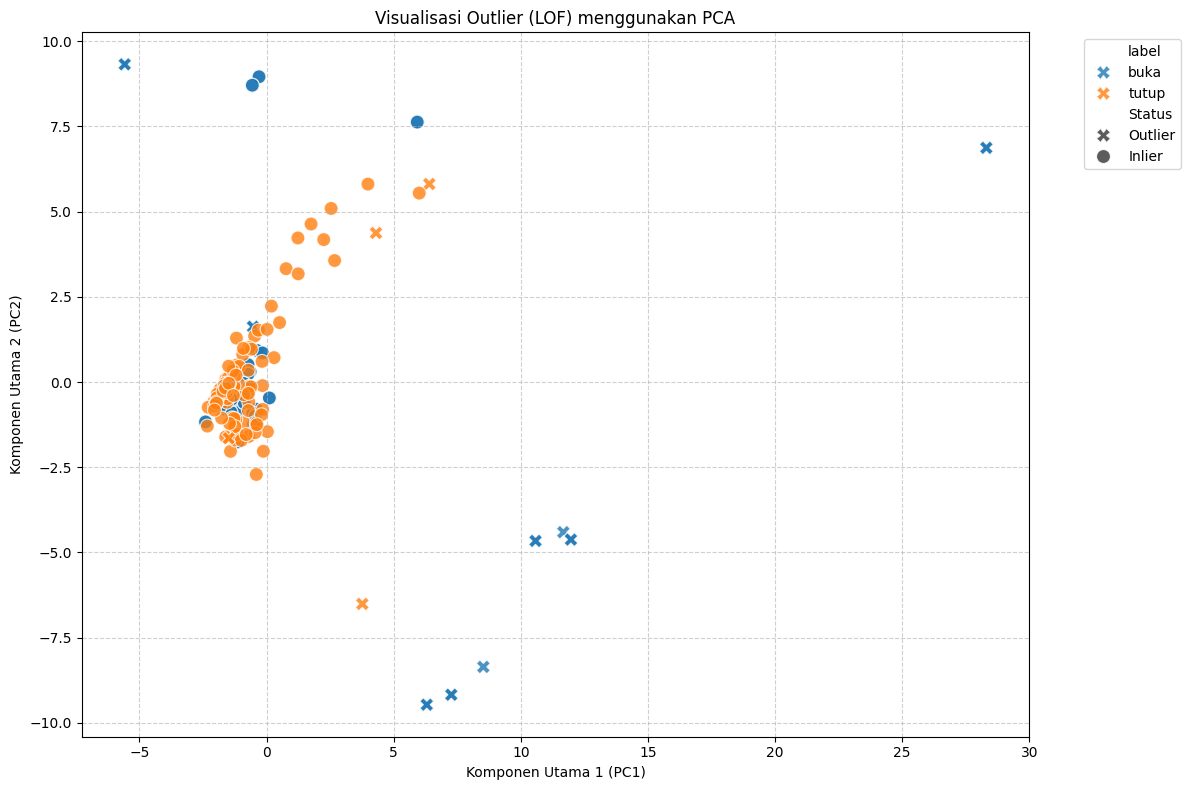

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA

# Pastikan variabel df_combined ada dari sel sebelumnya
if 'df_combined' in locals() and not df_combined.empty:

    print("--- 1. Analisis Nilai Kosong (Missing Values) ---")

    # Hitung nilai kosong per kolom
    missing_values = df_combined.isnull().sum()

    # Tampilkan HANYA kolom yang punya nilai kosong
    missing_data_cols = missing_values[missing_values > 0]

    if missing_data_cols.empty:
        print("✅ Tidak ada nilai kosong (missing values) di dalam dataset.\n")
    else:
        print("Kolom berikut memiliki nilai kosong:")
        print(missing_data_cols)

        # Visualisasikan pola nilai kosong dengan heatmap
        plt.figure(figsize=(15, 6))
        sns.heatmap(df_combined.isnull(), cbar=False, cmap='viridis', yticklabels=False)
        plt.title('Pola Nilai Kosong (Kuning = Hilang)')
        plt.show()

    # --- 2. Deteksi Outlier dengan Local Outlier Factor (LOF) ---

    print("\n--- 2. Deteksi Outlier (Local Outlier Factor) ---")

    # LOF hanya bisa berjalan pada data numerik
    # Kita pisahkan kolom non-numerik (filename, label)
    non_numeric_cols = ['filename', 'label']

    # Ambil semua kolom yang numerik
    numerical_features = [col for col in df_combined.columns if col not in non_numeric_cols]

    # Buat salinan data numerik
    X = df_combined[numerical_features].copy()

    # PENTING: LOF tidak bisa menangani data kosong.
    # Kita harus mengatasinya dulu. Cara termudah adalah menghapus baris yang kosong.
    # (Alternatif lain adalah imputasi, tapi drop lebih aman untuk deteksi outlier)

    # Simpan indeks asli sebelum di-drop
    original_indices = X.index

    # Drop baris yang punya NaN
    X_cleaned = X.dropna()

    # Catat berapa data yang di-drop
    rows_dropped = len(original_indices) - len(X_cleaned)
    if rows_dropped > 0:
        print(f"⚠️ Peringatan: {rows_dropped} baris dihapus karena mengandung nilai kosong sebelum menjalankan LOF.")

    if X_cleaned.empty:
        print("❌ GAGAL: Tidak ada data tersisa setelah menghapus nilai kosong. Tidak bisa menjalankan LOF.")
    else:
        # a. Scaling Data
        # LOF sensitif terhadap skala, jadi kita perlu menstandarisasi data
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_cleaned)

        # b. Inisialisasi dan Terapkan LOF
        # n_neighbors=20 adalah nilai umum, contamination=0.1 berarti kita asumsikan 10% data adalah outlier
        lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
        y_pred_lof = lof.fit_predict(X_scaled)

        # LOF akan memberi label -1 untuk outlier dan 1 untuk inlier
        # Dapatkan skor outliernya (semakin kecil/negatif, semakin outlier)
        lof_scores = lof.negative_outlier_factor_

        # Masukkan hasil LOF kembali ke DataFrame yang sudah bersih
        # Kita gunakan .loc untuk memastikan indeksnya cocok
        df_cleaned = df_combined.loc[X_cleaned.index].copy()
        df_cleaned['lof_score'] = lof_scores
        df_cleaned['is_outlier_lof'] = y_pred_lof

        # c. Tampilkan data yang terdeteksi sebagai outlier
        outliers_df = df_cleaned[df_cleaned['is_outlier_lof'] == -1].sort_values(by='lof_score')

        print(f"\n✅ LOF Selesai. Ditemukan {len(outliers_df)} outlier (dari {len(df_cleaned)} data bersih).")

        if not outliers_df.empty:
            print("--- Daftar Data Outlier (Paling Aneh Teratas) ---")
            # Tampilkan 10 outlier teratas
            display(outliers_df.head(10)[['filename', 'label', 'lof_score']])

        # d. Visualisasi Outlier
        # Karena kita punya 40+ fitur, kita tidak bisa memplotnya langsung.
        # Kita gunakan PCA untuk mengurangi dimensi jadi 2D agar bisa digambar.
        print("\nMembuat visualisasi PCA 2D dari Outlier...")

        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)

        # Buat DataFrame untuk plot
        df_plot = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
        df_plot['label'] = df_cleaned['label']
        # Ubah -1 (outlier) dan 1 (inlier) menjadi teks agar legenda lebih jelas
        df_plot['Status'] = np.where(df_cleaned['is_outlier_lof'] == -1, 'Outlier', 'Inlier')


        # Buat Scatter Plot
        plt.figure(figsize=(12, 8))
        sns.scatterplot(
            data=df_plot,
            x='PC1',
            y='PC2',
            hue='label',      # Warna berdasarkan label (buka/tutup)
            style='Status',   # Bentuk berdasarkan status (outlier/inlier)
            markers={'Inlier': 'o', 'Outlier': 'X'}, # Outlier ditandai 'X'
            s=100,            # Ukuran penanda
            alpha=0.8
        )
        plt.title('Visualisasi Outlier (LOF) menggunakan PCA')
        plt.xlabel('Komponen Utama 1 (PC1)')
        plt.ylabel('Komponen Utama 2 (PC2)')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

else:
    print("❌ GAGAL: Variabel 'df_combined' tidak ditemukan atau kosong. Harap jalankan sel kode sebelumnya terlebih dahulu.")

--- 1. Mempersiapkan Data (Menangani Missing Values) ---
✅ Nilai kosong (NaN) telah diisi menggunakan nilai rata-rata (mean).

--- 2. Normalisasi Data (Menggunakan RobustScaler) ---
✅ Data telah dinormalisasi menggunakan RobustScaler.
   (Skala data kini terpusat di median dan tahan terhadap outlier)

--- 3. Visualisasi Data Setelah Normalisasi ---
Membuat Box Plot untuk Fitur...


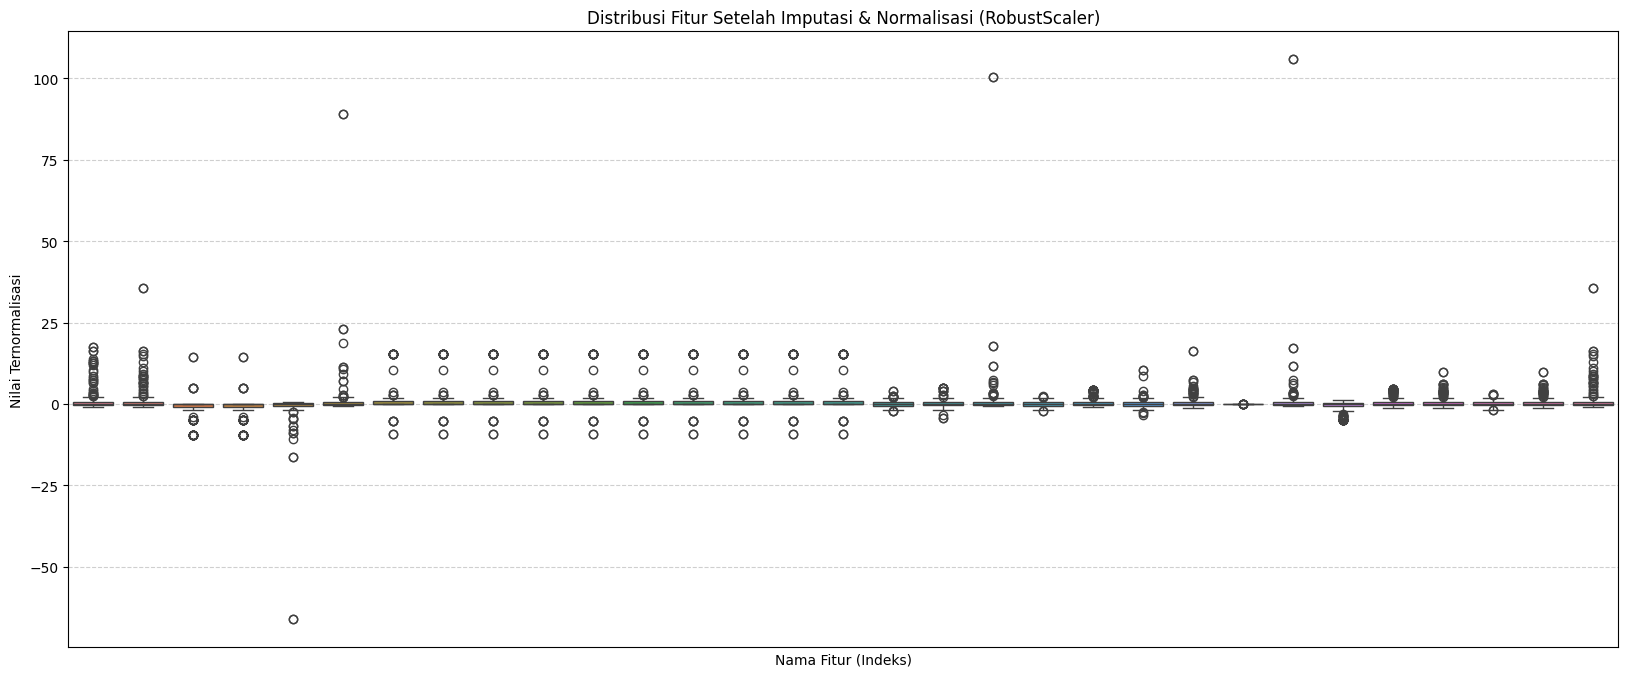


Membuat visualisasi PCA 3D dari data yang sudah bersih...


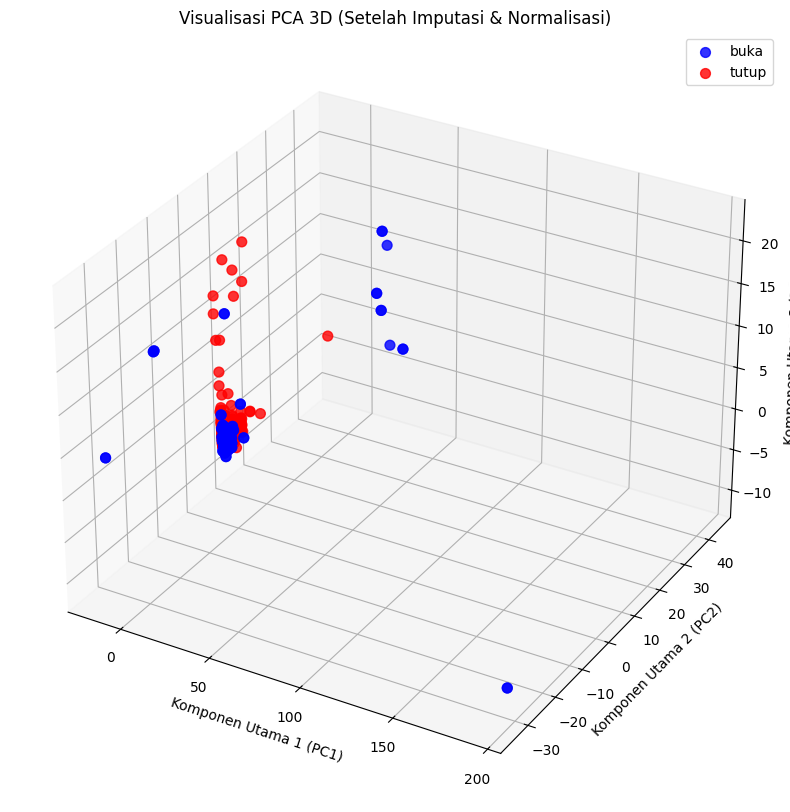

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from IPython.display import display
from mpl_toolkits.mplot3d import Axes3D # <-- Import untuk 3D

# Pastikan variabel df_combined ada dari sel sebelumnya
if 'df_combined' in locals() and not df_combined.empty:

    print("--- 1. Mempersiapkan Data (Menangani Missing Values) ---")

    # Pisahkan kolom non-numerik (label, filename)
    non_numeric_cols = ['filename', 'label']
    numeric_cols = [col for col in df_combined.columns if col not in non_numeric_cols]

    # Buat salinan data agar data asli tetap aman
    df_processed = df_combined.copy()

    # --- Gunakan SimpleImputer untuk mengisi nilai NaN ---
    imputer = SimpleImputer(strategy='mean')
    df_processed[numeric_cols] = imputer.fit_transform(df_processed[numeric_cols])
    print("✅ Nilai kosong (NaN) telah diisi menggunakan nilai rata-rata (mean).\n")

    # -----------------------------------------------------------------

    print("--- 2. Normalisasi Data (Menggunakan RobustScaler) ---")
    scaler = RobustScaler()
    df_processed[numeric_cols] = scaler.fit_transform(df_processed[numeric_cols])
    print("✅ Data telah dinormalisasi menggunakan RobustScaler.")
    print("   (Skala data kini terpusat di median dan tahan terhadap outlier)\n")

    # -----------------------------------------------------------------

    print("--- 3. Visualisasi Data Setelah Normalisasi ---")

    # --- Visualisasi A: Box Plot (Tetap 2D) ---
    print("Membuat Box Plot untuk Fitur...")
    plt.figure(figsize=(20, 8))
    sns.boxplot(data=df_processed[numeric_cols])
    plt.title('Distribusi Fitur Setelah Imputasi & Normalisasi (RobustScaler)')
    plt.xlabel('Nama Fitur (Indeks)')
    plt.ylabel('Nilai Ternormalisasi')
    plt.xticks([])
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # --- PERUBAHAN: Visualisasi B: PCA Plot 3D ---
    print("\nMembuat visualisasi PCA 3D dari data yang sudah bersih...")

    # PERUBAHAN: Ubah n_components menjadi 3
    pca = PCA(n_components=3)
    X_normalized = df_processed[numeric_cols]
    X_pca_normalized = pca.fit_transform(X_normalized)

    # PERUBAHAN: Buat DataFrame dengan 3 kolom (PC1, PC2, PC3)
    df_plot_normalized = pd.DataFrame(
        data=X_pca_normalized,
        columns=['PC1', 'PC2', 'PC3'], # <-- Tiga komponen
        index=df_processed.index
    )
    df_plot_normalized['label'] = df_processed['label']

    # --- Logika Plotting 3D dengan Matplotlib ---

    # Buat pemetaan warna dinamis berdasarkan label
    unique_labels = df_plot_normalized['label'].unique()
    colors = ['blue', 'red', 'green', 'purple', 'orange'] # Cadangan warna
    color_map = {label: colors[i] for i, label in enumerate(unique_labels)}

    # Buat figur 3D
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d') # <-- Inisialisasi plot 3D

    # Plot setiap label secara terpisah agar bisa diberi warna
    for label, color in color_map.items():
        subset = df_plot_normalized[df_plot_normalized['label'] == label]
        ax.scatter(
            subset['PC1'],
            subset['PC2'],
            subset['PC3'],
            c=color,
            label=label,
            s=50, # Ukuran titik
            alpha=0.8
        )

    ax.set_title('Visualisasi PCA 3D (Setelah Imputasi & Normalisasi)')
    ax.set_xlabel('Komponen Utama 1 (PC1)')
    ax.set_ylabel('Komponen Utama 2 (PC2)')
    ax.set_zlabel('Komponen Utama 3 (PC3)') # <-- Label Z
    ax.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

else:
    print("❌ GAGAL: Variabel 'df_combined' tidak ditemukan atau kosong. Harap jalankan sel kode sebelumnya terlebih dahulu.")


--- 1. Memuat Dataset (Minimal 'buka' dan 'tutup') ---
✅ Berhasil memuat 'all_audio_buka_statistical_features.csv' (Total: 100 baris)
✅ Berhasil memuat 'all_audio_tutup_statistical_features.csv' (Total: 100 baris)
⚠️ INFO: File opsional 'all_audio_unknown_statistical_features.csv' tidak ditemukan. Model akan dilatih sebagai 2-kelas (buka/tutup).

--- 2. Model akan dilatih dengan 2 kelas ---
Distribusi Data (Sebelum SMOTE):
label
buka     100
tutup    100
Name: count, dtype: int64

--- 3. Mengisi nilai kosong (NaN) menggunakan 'mean' ---

--- 4. Menjalankan SMOTE untuk menyeimbangkan data latih... ---
Distribusi Data Latih (Setelah SMOTE):
label
buka     80
tutup    80
Name: count, dtype: int64

--- 5. Menerapkan PCA (n=30) ---
✅ Reduksi dimensi berhasil. Data latih: (160, 28), Data uji: (40, 28)

--- 6. Menjalankan RobustScaler ---

--- 7. Melatih model Random Forest Classifier... ---
✅ Model berhasil dilatih!

--- 8. Hasil dan Akurasi Model (pada Data Uji) ---
   AKURASI MODEL: 100.00

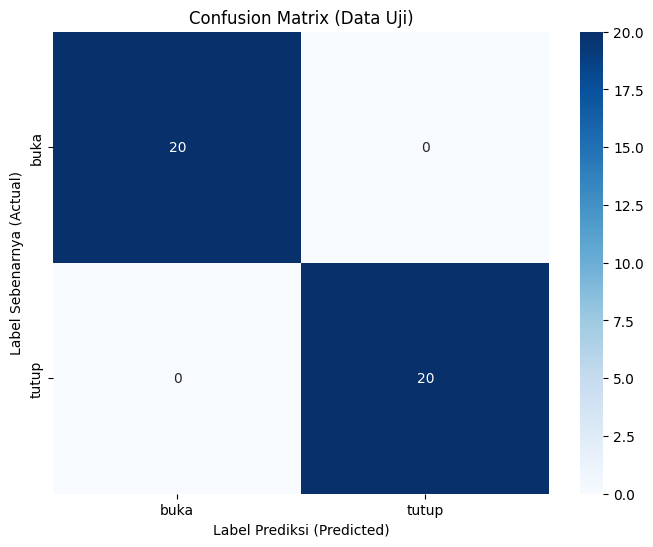


--- 9. Menyimpan 4 file artifact... ---
✅ Model disimpan sebagai 'model_suara_classifier.joblib'
✅ Imputer disimpan sebagai 'imputer.joblib'
✅ Scaler disimpan sebagai 'scaler.joblib'
✅ PCA disimpan sebagai 'pca.joblib'

Harap unggah 4 file .joblib baru ini ke aplikasi Streamlit Anda.


In [ ]:
# PERINTAH INSTALASI: Jalankan ini di sel pertama
# !pip install pandas numpy matplotlib seaborn joblib scikit-learn tsfel librosa imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE # <-- IMPORT ALGORITMA PENYEIMBANG
from sklearn.decomposition import PCA # <-- PASTIKAN INI DI-IMPORT
from IPython.display import display
import os

print("--- 1. Memuat Dataset (Minimal 'buka' dan 'tutup') ---")

# --- Tentukan Nama File ---
file_buka = 'all_audio_buka_statistical_features.csv'
file_tutup = 'all_audio_tutup_statistical_features.csv'
file_unknown = 'all_audio_unknown_statistical_features.csv' # <-- DATA BARU (Opsional)

list_dataframes = []
data_wajib_lengkap = True

# --- Muat dan beri label data 'buka' ---
try:
    df_buka = pd.read_csv(file_buka)
    df_buka['label'] = 'buka'
    list_dataframes.append(df_buka)
    print(f"✅ Berhasil memuat '{file_buka}' (Total: {df_buka.shape[0]} baris)")
except FileNotFoundError:
    print(f"❌ GAGAL: File Wajib '{file_buka}' tidak ditemukan.")
    data_wajib_lengkap = False

# --- Muat dan beri label data 'tutup' ---
try:
    df_tutup = pd.read_csv(file_tutup)
    df_tutup['label'] = 'tutup'
    list_dataframes.append(df_tutup)
    print(f"✅ Berhasil memuat '{file_tutup}' (Total: {df_tutup.shape[0]} baris)")
except FileNotFoundError:
    print(f"❌ GAGAL: File Wajib '{file_tutup}' tidak ditemukan.")
    data_wajib_lengkap = False

# --- Muat data 'unknown' (sekarang opsional) ---
try:
    df_unknown = pd.read_csv(file_unknown)
    df_unknown['label'] = 'unknown'
    list_dataframes.append(df_unknown)
    print(f"✅ Berhasil memuat file opsional '{file_unknown}' (Total: {df_unknown.shape[0]} baris)")
except FileNotFoundError:
    print(f"⚠️ INFO: File opsional '{file_unknown}' tidak ditemukan. Model akan dilatih sebagai 2-kelas (buka/tutup).")

if data_wajib_lengkap:

    # --- 2. Gabungkan dan Pra-pemrosesan Awal ---
    df_combined = pd.concat(list_dataframes, ignore_index=True)

    print(f"\n--- 2. Model akan dilatih dengan {len(list_dataframes)} kelas ---")
    print("Distribusi Data (Sebelum SMOTE):")
    print(df_combined['label'].value_counts())

    non_numeric_cols = ['filename', 'label']
    numeric_cols = [col for col in df_combined.columns if col not in non_numeric_cols]

    X = df_combined[numeric_cols]
    y = df_combined['label']

    # --- 3. Mengisi Nilai Kosong (Imputasi) ---
    print("\n--- 3. Mengisi nilai kosong (NaN) menggunakan 'mean' ---")
    # Imputer akan disimpan untuk digunakan di Streamlit
    imputer = SimpleImputer(strategy='mean')
    X_imputed = imputer.fit_transform(X)
    X = pd.DataFrame(X_imputed, columns=numeric_cols)

    # --- 4. Membagi Data: 80% Latih, 20% Uji ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # --- 5. ALGORITMA SMOTE & PCA (HANYA PADA DATA LATIH) ---
    print("\n--- 4. Menjalankan SMOTE untuk menyeimbangkan data latih... ---")
    smote = SMOTE(random_state=42)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
    print("Distribusi Data Latih (Setelah SMOTE):")
    print(y_train_balanced.value_counts())

    # --- PERBAIKAN PIPELINE: Terapkan PCA ---
    print("\n--- 5. Menerapkan PCA (n=30) ---")
    pca = PCA(n_components=28)
    # Latih PCA (fit_transform) HANYA pada data latih
    X_train_pca = pca.fit_transform(X_train_balanced)

    # Terapkan PCA yang sama (transform) pada data uji
    # PERHATIAN: X_test tidak di-SMOTE, itu sudah benar.
    X_test_pca = pca.transform(X_test)
    print(f"✅ Reduksi dimensi berhasil. Data latih: {X_train_pca.shape}, Data uji: {X_test_pca.shape}")

    # --- 6. Normalisasi Data (Scaling) ---
    print("\n--- 6. Menjalankan RobustScaler ---")
    # Scaler akan disimpan untuk digunakan di Streamlit
    scaler = RobustScaler()

    # PERBAIKAN: Latih scaler pada data latih yang sudah di-PCA
    X_train_scaled = scaler.fit_transform(X_train_pca)

    # PERBAIKAN: Terapkan scaler pada data uji yang sudah di-PCA
    X_test_scaled = scaler.transform(X_test_pca)

    # --- 7. Melatih Model Klasifikasi ---
    print("\n--- 7. Melatih model Random Forest Classifier... ---")
    # Model akan disimpan untuk digunakan di Streamlit
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train_scaled, y_train_balanced)
    print("✅ Model berhasil dilatih!\n")

    # --- 8. Mengevaluasi Model ---
    print("--- 8. Hasil dan Akurasi Model (pada Data Uji) ---")
    # PERBAIKAN: Prediksi pada data X_test_scaled (yang sudah benar)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)

    print("============================================")
    print(f"   AKURASI MODEL: {accuracy * 100:.2f} %   ")
    print("============================================")

    print("\nLaporan Klasifikasi (Classification Report):")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title('Confusion Matrix (Data Uji)')
    plt.ylabel('Label Sebenarnya (Actual)')
    plt.xlabel('Label Prediksi (Predicted)')
    plt.show()

    # --- 9. Menyimpan Model ---
    # PERHATIAN: Kita sekarang harus menyimpan PCA juga!
    print("\n--- 9. Menyimpan 4 file artifact... ---")
    joblib.dump(model, 'model_suara_classifier.joblib')
    joblib.dump(imputer, 'imputer.joblib')
    joblib.dump(scaler, 'scaler.joblib')
    joblib.dump(pca, 'pca.joblib') # <-- FILE BARU YANG WAJIB DISIMPAN

    print("✅ Model disimpan sebagai 'model_suara_classifier.joblib'")
    print("✅ Imputer disimpan sebagai 'imputer.joblib'")
    print("✅ Scaler disimpan sebagai 'scaler.joblib'")
    print("✅ PCA disimpan sebagai 'pca.joblib'")
    print("\nHarap unggah 4 file .joblib baru ini ke aplikasi Streamlit Anda.")

else:
    print("\n❌ GAGAL: Data tidak cukup. Pastikan minimal file 'buka' dan 'tutup' CSV ada di folder yang sama.")


## Evaluasi
dari hasil prediksi semua data bergantung pada fitur statistik sehingga suara tidak menemukan pembeda yang membuat model selalu memprediksi buka

link dataset
https://drive.google.com/drive/folders/16e80DwDgUzjX7d69ZZwuWDMYGxYQM31j?usp=sharing

link website

https://prediksisuara.streamlit.app/